Average high-water date: May 11 (day 130.7)
Average low-water date:  November 27 (day 331.3)


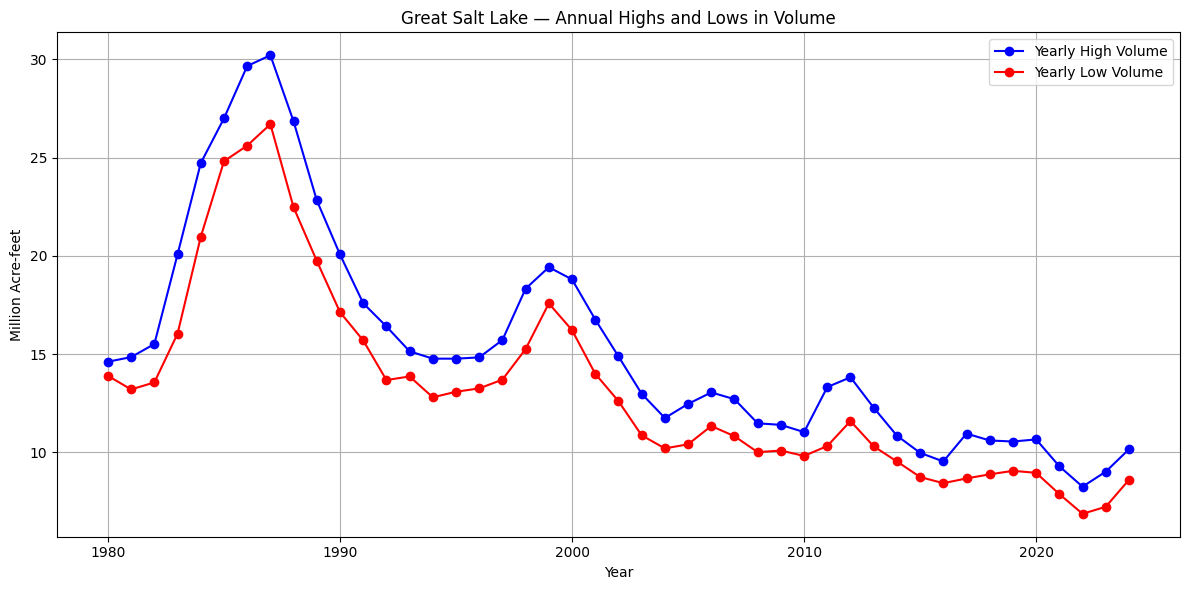

SystemExit: 

C:\Users\thoma\anaconda3\Lib\site-packages\IPython\core\interactiveshell.py:3585: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [3]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Created on Wed Aug 27 22:24:44 2025

@author: Matt
"""


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys

# --- Load data ---
df = pd.read_csv("GSLLevelVol.csv")
midpoint = int(len(df)/2)
uppermid = int((midpoint + len(df))/2)
df = df.iloc[uppermid:,:]
date_col = df.columns[0]
volume_col = "Total_vol_m3"

df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
df = df.dropna(subset=[date_col])
df = df.sort_values(date_col)
df["Year"] = df[date_col].dt.year

# --- Annual Highs and Lows ---
idx_max = df.groupby("Year")[volume_col].idxmax().dropna()
idx_min = df.groupby("Year")[volume_col].idxmin().dropna()

yearly_max = df.loc[idx_max].copy()
yearly_min = df.loc[idx_min].copy()

yearly_max["doy"] = yearly_max[date_col].dt.dayofyear
yearly_min["doy"] = yearly_min[date_col].dt.dayofyear

# --- Circular mean for dates ---
def circular_mean_doy(doys, year_length=365):
    radians = 2 * np.pi * (doys / year_length)
    mean_angle = np.arctan2(np.mean(np.sin(radians)), np.mean(np.cos(radians)))
    if mean_angle < 0:
        mean_angle += 2 * np.pi
    return mean_angle / (2 * np.pi) * year_length

def doy_to_md(doy):
    base = pd.Timestamp("2001-01-01")  # non-leap reference
    return (base + pd.Timedelta(days=int(round(doy)) - 1)).strftime("%B %d")

avg_max_doy = circular_mean_doy(yearly_max["doy"].values)
avg_min_doy = circular_mean_doy(yearly_min["doy"].values)

print(f"Average high-water date: {doy_to_md(avg_max_doy)} (day {avg_max_doy:.1f})")
print(f"Average low-water date:  {doy_to_md(avg_min_doy)} (day {avg_min_doy:.1f})")

# --- Plot annual highs & lows ---
year_max_af = (yearly_max[volume_col]/1233.48)/1000000
year_min_af = (yearly_min[volume_col]/1233.48)/1000000

plt.figure(figsize=(12, 6))
plt.plot(yearly_max["Year"], year_max_af, 'o-', color="blue", label="Yearly High Volume")
plt.plot(yearly_min["Year"], year_min_af, 'o-', color="red",  label="Yearly Low Volume")
plt.xlabel("Year")
plt.ylabel("Million Acre-feet")
plt.title("Great Salt Lake — Annual Highs and Lows in Volume")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

sys.exit()

# # --- Unit Conversions ---
# whale_unit = 204.0  # m³ per whale
# gallons_to_m3 = 0.00378541
# slc_population = 1_300_000
# water_per_person_year = 100 * 365 * gallons_to_m3  # m³ per person per year
# slc_consumption_year = water_per_person_year * slc_population  # total m³/year

# avg_lake_volume = df[volume_col].mean()  # average lake volume in dataset

# df["Whales"] = df[volume_col] / whale_unit
# df["Lake_Ratio"] = df[volume_col] / avg_lake_volume
# df["SLC_WaterYears"] = df[volume_col] / slc_consumption_year
# df["Meters3"] = df[volume_col]  # just to keep naming consistent

# # --- Plot time series in different units ---
# fig, axes = plt.subplots(4, 1, figsize=(12, 14), sharex=True)

# df.plot(x=date_col, y="Whales", ax=axes[0], color="blue", legend=False)
# axes[0].set_ylabel("Whales")
# axes[0].set_title("Lake Volume in Whale Units")

# df.plot(x=date_col, y="Lake_Ratio", ax=axes[1], color="green", legend=False)
# axes[1].set_ylabel("× Avg Lake Volume")
# axes[1].set_title("Lake Volume Relative to Average")

# df.plot(x=date_col, y="SLC_WaterYears", ax=axes[2], color="purple", legend=False)
# axes[2].set_ylabel("SLC water-years")
# axes[2].set_title("Lake Volume in Salt Lake City's Annual Water Consumption")

# df.plot(x=date_col, y="Meters3", ax=axes[3], color="black", legend=False)
# axes[3].set_ylabel("m³")
# axes[3].set_title("Lake Volume in Cubic Meters")

# plt.xlabel("Date")
# plt.tight_layout()
# plt.show()
